In [8]:
import numpy as np
import matplotlib.pyplot as plt
import autograd.numpy as anp
from autograd import grad

In [9]:
# i want to create 4 random lines
mL = np.random.randn(4, 3)
vN = np.linalg.norm(mL[:, 0:2], axis=1) # vector normas
print("vN vector shape is: ", vN.shape)
print("vN[:, None] shape is", vN[:,None].shape) 
mL = mL / vN[:,None] # normalization of lines

vN vector shape is:  (4,)
vN[:, None] shape is (4, 1)


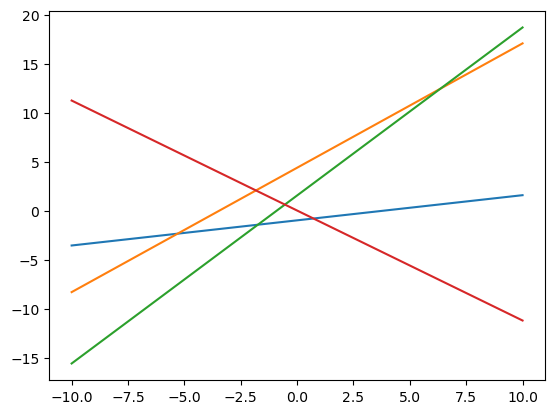

In [10]:
# now i want to draw all these 4 lines
mY = mL[:,[0, 2]] / mL[:, 1][:, None]
vX = np.linspace(-10, 10, 101)
fig, ax = plt.subplots()
for row in mY:
    ax.plot(vX, row[0] * vX + row[1])
plt.show()

In [11]:
# now i want to build a function which calculate the sum of squares of distances between point and all the lines
def sum_squares_distances(point, mL):
    result = 0
    for row in mL:
        result += (row[0] * point[0] + row[1] * point[1] + row[2]) ** 2

    return result

In [17]:
fun = lambda vX: sum_squares_distances(vX, mL)
grad_fun = grad(fun)

point = np.array([[5], [5]]) # initial point as a column vector
num_iter = 1000
step = 0.01

# building of trajectory path
trajectory = [point.copy()]
for _ in range(num_iter):
    point = point - step * grad_fun(point)
    trajectory.append(point.copy())
trajectory = np.array(trajectory)


In [18]:
point.shape

(2, 1)

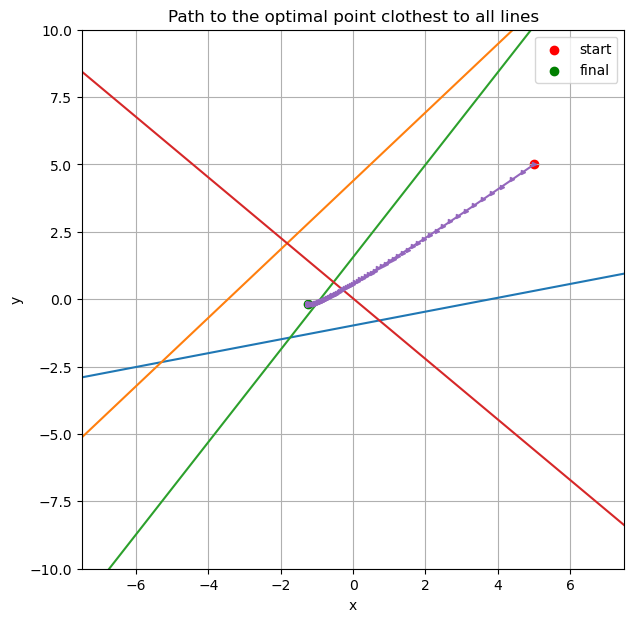

In [23]:
fig, ax = plt.subplots(figsize=(7,7))
for row in mY:
    ax.plot(vX, row[0] * vX + row[1])

ax.plot(trajectory[:,0], trajectory[:,1], '->', markersize=3)
ax.scatter(trajectory[0,0], trajectory[0,1], color='red', label='start')
ax.scatter(trajectory[-1,0], trajectory[-1,1], color='green', label='final')
ax.grid(True)
ax.legend()
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Path to the optimal point clothest to all lines')
ax.set_xlim(-7.5, 7.5)
ax.set_ylim(-10, 10)
plt.show()